In [3]:
# STEP 1: IMPORTS AND SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)


In [4]:
# STEP 2: LOAD DATA
# Use relative path from notebook location
notebook_dir = Path.cwd()
data_path = notebook_dir.parent / 'data' / 'raw' / 'heart_disease_uci.csv'

print(f"Loading from: {data_path}")

df = pd.read_csv(data_path)

print("✓ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loading from: D:\Sutathip003.github.io\Projects\Heart disease project\Aooold Original code\data\raw\heart_disease_uci.csv
✓ Dataset loaded successfully!
Shape: 920 rows × 16 columns


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
#check columps
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

## STEP 1: DATA UNDERSTANDING

**Dataset Source:** https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data 
**Task:** Binary Classification - Predict heart disease presence

### Feature Dictionary
- **id**: Patient identifier
- **age**: Patient age (years)
- **sex**: 1=male, 0=female
- **dataset**: Data collection location
- **cp**: Chest pain type (0-3, ordered by severity)
- **trestbps**: Resting blood pressure (mmHg)
- **chol**: Serum cholesterol (mg/dL)
- **fbs**: Fasting blood sugar > 120 mg/dL
- **restecg**: ECG at rest
- **thalach**: Maximum heart rate achieved
- **exang**: Exercise-induced angina
- **oldpeak**: ST depression (ECG change)
- **slope**: ST segment slope
- **ca**: Number of major vessels (0-3)
- **thal**: Thallium stress test
- **num**: TARGET - Heart disease (0=no, 1-4=yes, levels of severity)

In [2]:
df['thal'].head()

NameError: name 'df' is not defined

# STEP 2: STRUCTURAL ANALYSIS

In [6]:
# Dataset structure
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.info()

Dataset Info:
Shape: (920, 16)

Memory usage: 0.40 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [309]:
df.sample(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
728,729,60,Male,VA Long Beach,non-anginal,120.0,0.0,NaN,normal,141.0,True,2.0,upsloping,NaN,NaN,3
480,481,58,Male,Hungary,asymptomatic,135.0,222.0,False,normal,100.0,False,0.0,NaN,NaN,NaN,0
312,313,34,Female,Hungary,atypical angina,130.0,161.0,False,normal,190.0,False,0.0,NaN,NaN,NaN,0
203,204,64,Female,Cleveland,non-anginal,140.0,313.0,False,normal,133.0,False,0.2,upsloping,0.0,reversable defect,0
531,532,40,Female,Hungary,asymptomatic,150.0,392.0,False,normal,130.0,False,2.0,flat,NaN,fixed defect,1


 # STEP 3: DATA QUALITY CHECK
       

In [6]:
# Check missing value
missing = df.isnull().sum()
missing_ratio = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_ratio (%)': missing_ratio
})

print(missing_df.sort_values(by='missing_ratio (%)', ascending=False))

          missing_count  missing_ratio (%)
ca                  611              66.41
thal                486              52.83
slope               309              33.59
fbs                  90               9.78
oldpeak              62               6.74
trestbps             59               6.41
thalch               55               5.98
exang                55               5.98
chol                 30               3.26
restecg               2               0.22
id                    0               0.00
age                   0               0.00
sex                   0               0.00
dataset               0               0.00
cp                    0               0.00
num                   0               0.00


In [11]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [312]:
#Check duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


## STEP 4: DATA CLEANING & PREPARATION

In [12]:
# Create working copy
df_clean = df.copy()

# Rename target column for clarity
df_clean.rename(columns={'num': 'target'}, inplace=True)

# Convert target to binary (0=no disease, 1=disease present)
df_clean['target_binary'] = (df_clean['target'] > 0).astype(int)

print("✓ Data preparation complete!")

✓ Data preparation complete!


In [313]:
#Chack text preprocessing: normalize strings, remove whitespace, and enforce consistent data types 

# change target name
target = df.rename(columns={'num':'target'}, inplace=True)

id_cols = ['id']
target_col = target
id_target_col = id_cols + [target_col]

issues_report = {}


for col in df.columns:
 
    if col in id_target_col:
        continue

    values = df[col].dropna()
    issues_report[col] = []

    if df[col].dtype == 'object':
        
        str_vals = values.astype(str)

        # 1. Leading / trailing whitespace
        if (str_vals != str_vals.str.strip()).any():
            issues_report[col].append("Has leading/trailing whitespace")

        # 2. Multiple internal spaces
        if str_vals.str.contains(r'\s{2,}', regex=True).any():
            issues_report[col].append("Has multiple internal spaces")

        # 3. Case inconsistency
        if str_vals.str.lower().nunique() != str_vals.nunique():
            issues_report[col].append("Case inconsistency (e.g., Yes vs yes)")

        # 4. Boolean stored as string
        normalized = str_vals.str.strip().str.lower()
        unique_vals = set(normalized.unique())

        if unique_vals.issubset({'true','false','yes','no','y','n','0','1'}):
            issues_report[col].append("Boolean stored as STRING")

        # 5. Detect numeric stored as string
        if str_vals.str.replace('.', '', regex=False).str.isnumeric().all():
            issues_report[col].append("Numeric stored as STRING") 

# Report chacking
for col, issues in issues_report.items():
    if issues:
        print(f"\n ! {col}")
        for issue in issues:
            print(f"   - {issue}")
            


 ! fbs
   - Boolean stored as STRING

 ! exang
   - Boolean stored as STRING


# STEP 4 DATA CLEANING 

In [294]:
# HANDLES MISSING VALUES NUMERICAL COLUMNS
numerical_cols=[]

# columns where 0 is INVALID
cols_invalid_zero = ['chol', 'trestbps', 'thalch']

for col in df.columns:

    if df[col].dtype == "object":
        continue

    #replace 0 for specific columns
    if col in cols_invalid_zero:
        df[col] = df[col].replace(0, np.nan)

    null_ratio = df[col].isnull().mean()

    # Drop high missing value
    if null_ratio > 0.3:
        print(f"\nDROP → {col}: {null_ratio:.2f}")
        df.drop(columns=[col],axis=1, inplace=True)
        continue
          
    # fill moderate missing with median
    elif null_ratio > 0:
        print(f"\nnull_ratio [{col}] : {null_ratio:.2f}")
        median_value = df[col].median()
        df[col] = df[col].fillna(df[col].median()) 
        print(f"{col}': filled with median {median_value}")

    # Handle value          
    numerical_cols.append(col)    


null_ratio [trestbps] : 0.06
trestbps': filled with median 130.0

null_ratio [chol] : 0.03
chol': filled with median 223.0

null_ratio [thalch] : 0.06
thalch': filled with median 140.0

null_ratio [oldpeak] : 0.07
oldpeak': filled with median 0.5

DROP → ca: 0.66
Before drop: Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal',
       'target'],
      dtype='object')
After drop: Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'target'],
      dtype='object')


In [295]:
for col in numerical_cols:
    if 0 in df[col].unique():
        print(f'missing value in : {col}')

missing value in : trestbps
missing value in : chol
missing value in : oldpeak


In [296]:
# HANDLES MISSING VALUES CATEGORICAL AND BINARY COLUMNS

col_summary = []
binary_cols = []
categorical_cols = []

for col in df.columns:

    if col in numerical_cols: 
        continue
    
    #CLEAN TEXT 
    if df[col].dtype == "object":

        # normalize values (lowercase, string)
        df[col] = df[col].astype(str).str.strip().str.lower()
        df[col] = df[col].replace(['nan', '<na>'], pd.NA)
        
        unique_vals = set(df[col].dropna().unique())
        len_unique_vals = len(unique_vals)

        col_summary.append((col, len_unique_vals, unique_vals))


col_summary = sorted(col_summary, key=lambda x: (x[1] != 2, x[1]))

# Classification 
for col, length, values in col_summary:
    if length == 2:
        binary_cols.append(col)       
        print(f"\nBinary column detected: {col}")
        print(f"len = {length}: {values}")        
    else:
        categorical_cols.append(col)
        print(f"\nUnique values: {col}")
        print(f"len = {length}: {values}")
        


Binary column detected: sex
len = 2: {'male', 'female'}

Binary column detected: fbs
len = 2: {'true', 'false'}

Binary column detected: exang
len = 2: {'true', 'false'}

Unique values: restecg
len = 3: {'lv hypertrophy', 'st-t abnormality', 'normal'}

Unique values: slope
len = 3: {'upsloping', 'flat', 'downsloping'}

Unique values: thal
len = 3: {'fixed defect', 'reversable defect', 'normal'}

Unique values: dataset
len = 4: {'hungary', 'cleveland', 'switzerland', 'va long beach'}

Unique values: cp
len = 4: {'asymptomatic', 'typical angina', 'atypical angina', 'non-anginal'}


In [297]:
# ENCODE AND FILL MISSING VALUE TO BINARY COLUMNS
for col in df.columns:
    
    if col in numerical_cols: 
        continue
    
    if col in binary_cols:

        unique_vals = set(df[col].dropna().unique())
    
        # case 1: true/false
        if unique_vals.issubset({'true', 'false'}):        
            df[col] = df[col].map({'true': 1, 'false': 0}) 
            print(f"{col} fill : {unique_vals}")
        
        # case 2: male/female
        elif unique_vals.issubset({'male', 'female'}):
            df[col] = df[col].map({'male': 1, 'female': 0})
            print(f"{col}: {unique_vals}")
        
        else:
            print(f"{col}: out of case → {unique_vals}")
    
         # FILL MISSING VALUES
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"{col}: filled with mode {mode_val}")


sex: {'male', 'female'}
fbs fill : {'true', 'false'}
fbs: filled with mode 0.0
exang fill : {'true', 'false'}
exang: filled with mode 0.0


In [298]:
# ENDCODE AND FILL MISSING VALUE TO CATEGORICAL COLUMNS

#creat mapping of ordinal data
ordinal_mappings = {
    'cp': {
        'typical angina': 0,
        'atypical angina': 1,
        'non-anginal': 2,
        'asymptomatic': 3
    },
    'restecg': {
        'normal': 0,
        'st-t abnormality': 1,
        'lv hypertrophy': 2
    },
    'slope': {
        'upsloping': 0,
        'flat': 1,
        'downsloping': 2
    },
    'thal': {
        'normal': 0,
        'fixed defect': 1,
        'reversable defect': 2
    }
}

for col, mapping in ordinal_mappings.items():

    if col in categorical_cols:

        df[col] = df[col].map(mapping)
        print(f"\n{col}: {mapping}")

        # fill missing ordinal column encoding
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"{col} → filled missing with mode: {mode_val}")
      


cp: {'typical angina': 0, 'atypical angina': 1, 'non-anginal': 2, 'asymptomatic': 3}

restecg: {'normal': 0, 'st-t abnormality': 1, 'lv hypertrophy': 2}
restecg → filled missing with mode: 0.0

slope: {'upsloping': 0, 'flat': 1, 'downsloping': 2}
slope → filled missing with mode: 1.0

thal: {'normal': 0, 'fixed defect': 1, 'reversable defect': 2}
thal → filled missing with mode: 0.0


In [299]:
#ENCODE AND FILL MISSING VALUES IN NOMINAL COLUMN (ONE-HOT)
nominal_cols = [col for col in categorical_cols if col not in ordinal_mappings]

# fill missing
for col in nominal_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# one-hot encoding
df = pd.get_dummies(df, columns=['dataset'], drop_first=True)

# check result
df.filter(like='dataset').head()

,dataset_hungary,dataset_switzerland,dataset_va long beach
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False


In [300]:
#FINAL VALIDATION
print("\n=== FINAL CHECK ===")
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

print("\n=== FINAL INFO ===")
df.info()

print("\n=== FINAL HEAD ===")
df.head()


=== FINAL CHECK ===
Missing values:
 id                       0
age                      0
sex                      0
cp                       0
trestbps                 0
chol                     0
fbs                      0
restecg                  0
thalch                   0
exang                    0
oldpeak                  0
slope                    0
thal                     0
target                   0
dataset_hungary          0
dataset_switzerland      0
dataset_va long beach    0
dtype: int64

Duplicates: 0

=== FINAL INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     920 non-null    int64  
 1   age                    920 non-null    int64  
 2   sex                    920 non-null    int64  
 3   cp                     920 non-null    int64  
 4   trestbps               920 non-nu

,id,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,target,dataset_hungary,dataset_switzerland,dataset_va long beach
0,1,63,1,0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,2.0,1.0,0,False,False,False
1,2,67,1,3,160.0,286.0,0.0,2.0,108.0,1.0,1.5,1.0,0.0,2,False,False,False
2,3,67,1,3,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1.0,2.0,1,False,False,False
3,4,37,1,2,130.0,250.0,0.0,0.0,187.0,0.0,3.5,2.0,0.0,0,False,False,False
4,5,41,0,1,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0.0,0.0,0,False,False,False


# STEP 5 EXPLORATORY DATA ANALYSIS (EDA)

In [301]:
# check target values balanced
df['target'].value_counts()
df['target'].value_counts(normalize=True)

target
0    0.446739
1    0.288043
2    0.118478
3    0.116304
4    0.030435
Name: proportion, dtype: float64

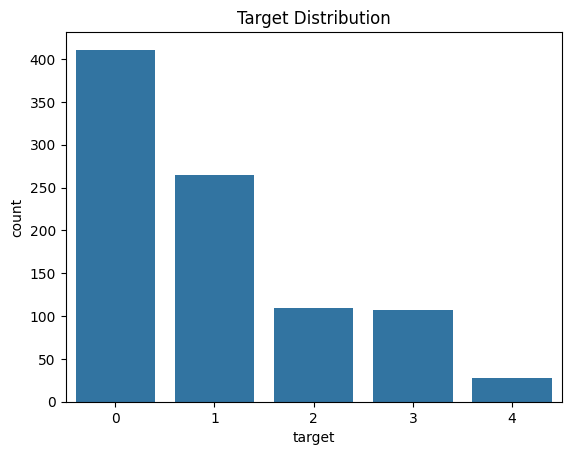

In [302]:
# Plot
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

The dataset is imbalanced. The majority class (target = 0) accounts for about 44.7%, while the smallest class (target = 4) is only about 3.0%.

-Non-disease (target = 0) ≈ 44.7%

-Heart disease (target = 1–4) ≈ 55.3%

Severe cases (class 4) are very low (~3%) → hardest to predict

In [303]:
numerical_cols

['trestbps', 'chol', 'thalch', 'oldpeak']

array([[<Axes: title={'center': 'trestbps'}>,
        <Axes: title={'center': 'chol'}>],
       [<Axes: title={'center': 'thalch'}>,
        <Axes: title={'center': 'oldpeak'}>]], dtype=object)

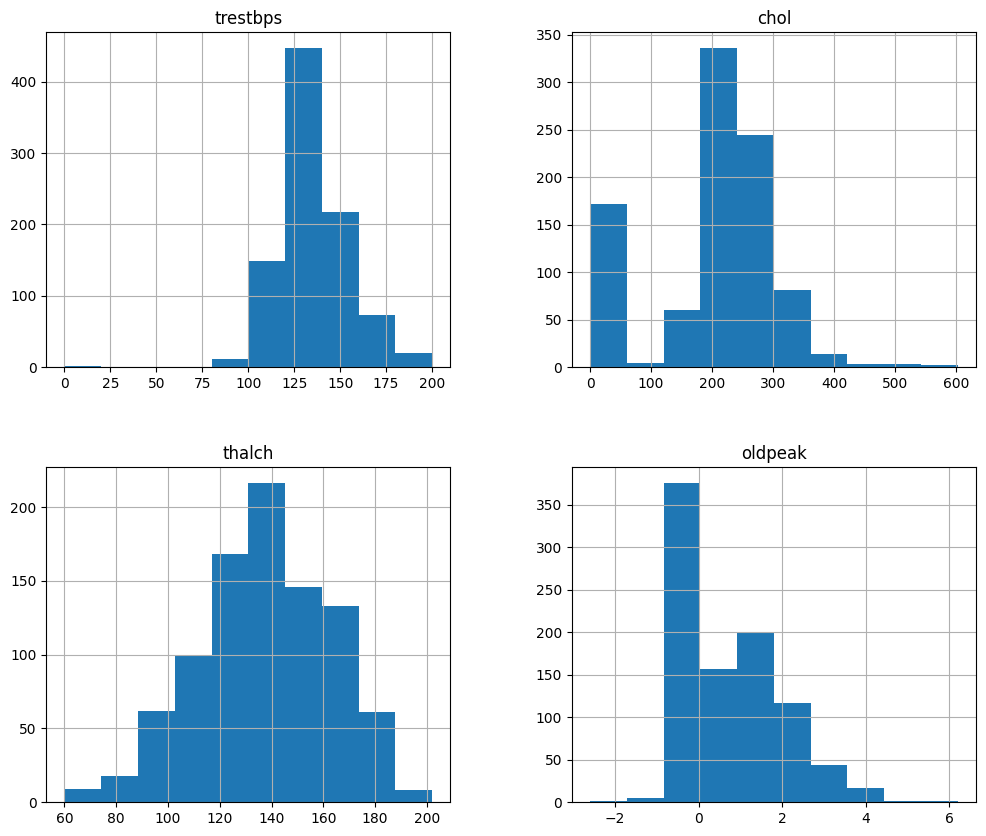

In [304]:
#Univariate Analysis

#Numerical_cols
df[numerical_cols].hist(figsize=(12, 10))
#Categoricol_cols

- **trestbps** shows slight right skew with most patients in normal blood pressure range, but some high-risk outliers exist.
- **chol** is heavily right-skewed with extreme outliers, indicating many patients have elevated cholesterol levels.
- **thalch** follows a near-normal distribution, making it a stable and reliable feature for modeling.
- **oldpeak** is strongly right-skewed, with most patients having low values but a few showing high cardiac stress indicators.

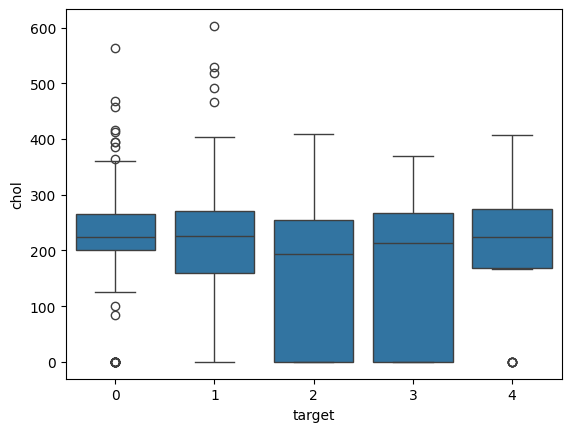

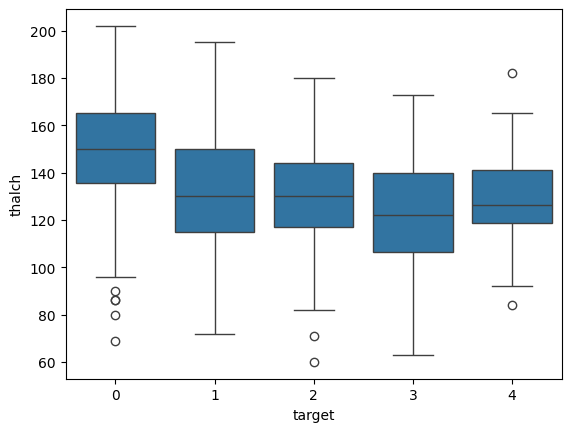

In [305]:
#Compare with target
sns.boxplot(x='target', y='chol', data=df)
plt.show()

sns.boxplot(x='target', y='thalch', data=df)
plt.show()